<a href="https://colab.research.google.com/github/svamsi319/Vamsi/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        if i < len(images):
            plt.subplot(n_row, n_col, i + 1)
            plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
            plt.title(titles[i], size=12)
            plt.xticks(())
            plt.yticks(())

In [4]:
# Loading the dataset
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Introspect the images arrays to find the shapes
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
n_features = X.shape[1]

# The label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("Total dataset size:")
print(f"n_samples: {n_samples}")
print(f"n_features: {n_features}")
print(f"n_classes: {n_classes}")

# Split into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


Extracting the top 150 eigenfaces from 966 faces


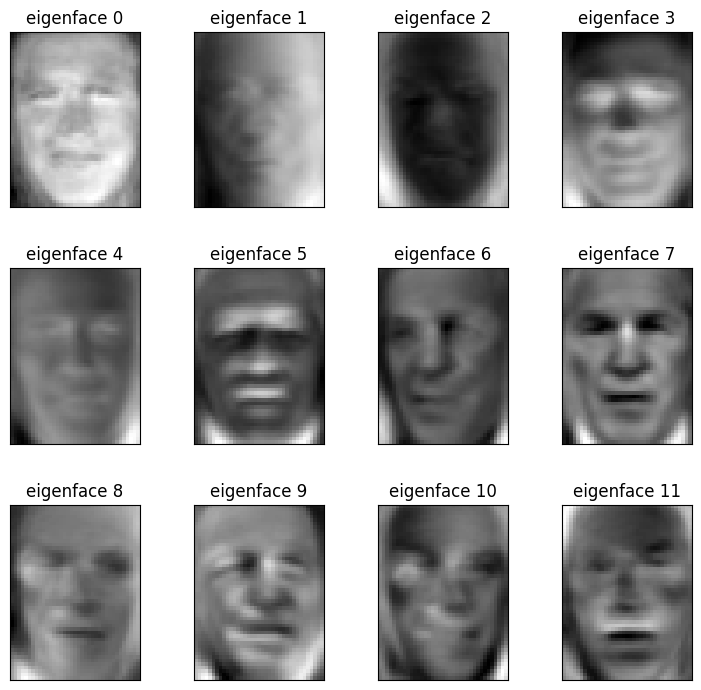

Project done...


In [5]:
# Compute PCA (Eigenfaces)
n_components = 150
print(f"Extracting the top {n_components} eigenfaces from {X_train.shape[0]} faces")

pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)
eigenfaces = pca.components_.reshape((n_components, h, w))

# Plot the most significant eigenfaces
eigenface_titles = [f"eigenface {i}" for i in range(12)]
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show()

# Project data onto eigenfaces
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Compute Fisherfaces (LDA)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_pca, y_train)

X_train_lda = lda.transform(X_train_pca)
X_test_lda = lda.transform(X_test_pca)
print("Project done...")

In [6]:
print("Training with Multi Layer Perceptron...")
clf = MLPClassifier(random_state=1, hidden_layer_sizes=(10, 10), max_iter=1000, verbose=True).fit(X_train_lda, y_train)

print("\nModel Weights Shapes:")
model_info = [coef.shape for coef in clf.coefs_]
print(model_info)

Training with Multi Layer Perceptron...
Iteration 1, loss = 2.23683778
Iteration 2, loss = 2.16996851
Iteration 3, loss = 2.10781069
Iteration 4, loss = 2.04878035
Iteration 5, loss = 1.99271907
Iteration 6, loss = 1.94029731
Iteration 7, loss = 1.89152318
Iteration 8, loss = 1.84565863
Iteration 9, loss = 1.80145893
Iteration 10, loss = 1.75959550
Iteration 11, loss = 1.72057174
Iteration 12, loss = 1.68150631
Iteration 13, loss = 1.64397917
Iteration 14, loss = 1.60704148
Iteration 15, loss = 1.57141698
Iteration 16, loss = 1.53600140
Iteration 17, loss = 1.50108763
Iteration 18, loss = 1.46746113
Iteration 19, loss = 1.43409165
Iteration 20, loss = 1.40091035
Iteration 21, loss = 1.36871321
Iteration 22, loss = 1.33698328
Iteration 23, loss = 1.30575527
Iteration 24, loss = 1.27495222
Iteration 25, loss = 1.24451294
Iteration 26, loss = 1.21461784
Iteration 27, loss = 1.18537912
Iteration 28, loss = 1.15672994
Iteration 29, loss = 1.12856817
Iteration 30, loss = 1.10092525
Iteration

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Accuracy: 85.71428571428571%


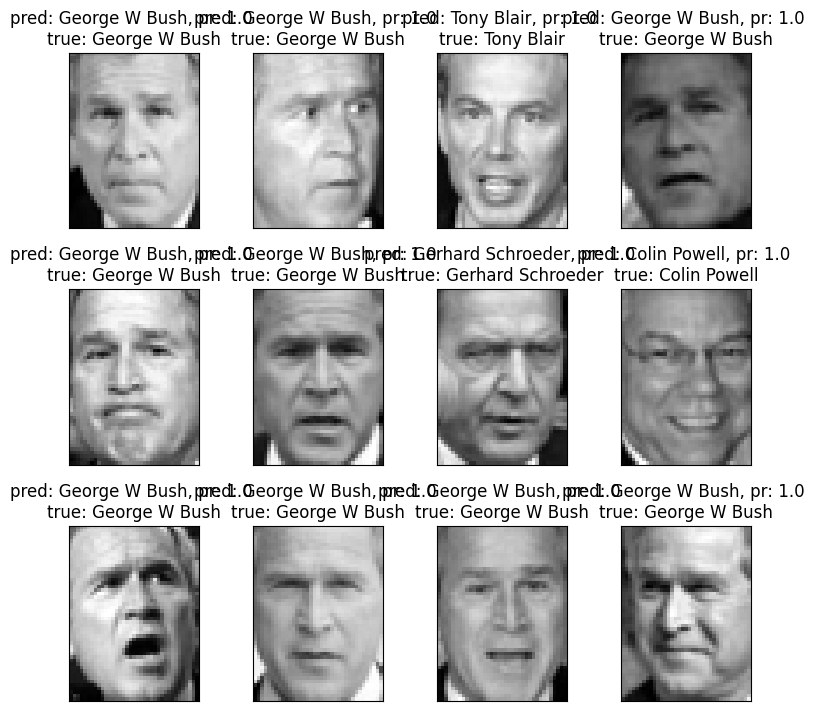

In [7]:
y_pred = clf.predict(X_test_lda)
y_prob = clf.predict_proba(X_test_lda)

# Preparing titles for the gallery
prediction_titles = []
true_positive = 0

for i in range(y_pred.shape[0]):
    true_name = target_names[y_test[i]]
    pred_name = target_names[y_pred[i]]

    # Format the result string as seen in your screenshot
    result = 'pred: %s, pr: %.1f \ntrue: %s' % (pred_name, np.max(y_prob[i]), true_name)
    prediction_titles.append(result)

    if true_name == pred_name:
        true_positive += 1

accuracy = (true_positive * 100) / y_pred.shape[0]
print(f"Accuracy: {accuracy}%")

# Plot final results
plot_gallery(X_test, prediction_titles, h, w)
plt.show()